In [1]:
import os
os.chdir("../")
configs_file = "train_fno_pi"

In [2]:
import os
from functools import partial

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from solidification.configs import load_configs
configs = load_configs(configs_file).Configs()

# from corrosion2d.configs import Configs
# configs = Configs()

from ggsci import pal_npg, pal_gsea
colors = pal_npg()(10)
import seaborn as sns
from matplotlib import font_manager
font_dir = "./helvetica/"
font_names = os.listdir(font_dir)
for font_name in font_names:
    font_manager.fontManager.addfont(font_dir + font_name)
# nature style
from matplotlib import rcParams
rcParams.update({
    "font.size": 7,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica",],
    "pdf.fonttype": 42,
    "figure.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
    # thin ticks
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    # thin axes
    "axes.linewidth": 0.5,
    # thin legend frame
    "legend.frameon": False,
    # set color_theme as ggsci
    "axes.prop_cycle": plt.cycler(color=[
        "#E64B35", "#4DBBD5", "#00A087",
        "#3C5488", "#F39B7F", "#8491B4",
        "#91D1C2", "#DC0000", "#7E6148", "#B09C85"
    ]),
    # "axes.prop_cycle": plt.cycler(color=colors),
})


Text(0, 0.5, 'Loss')

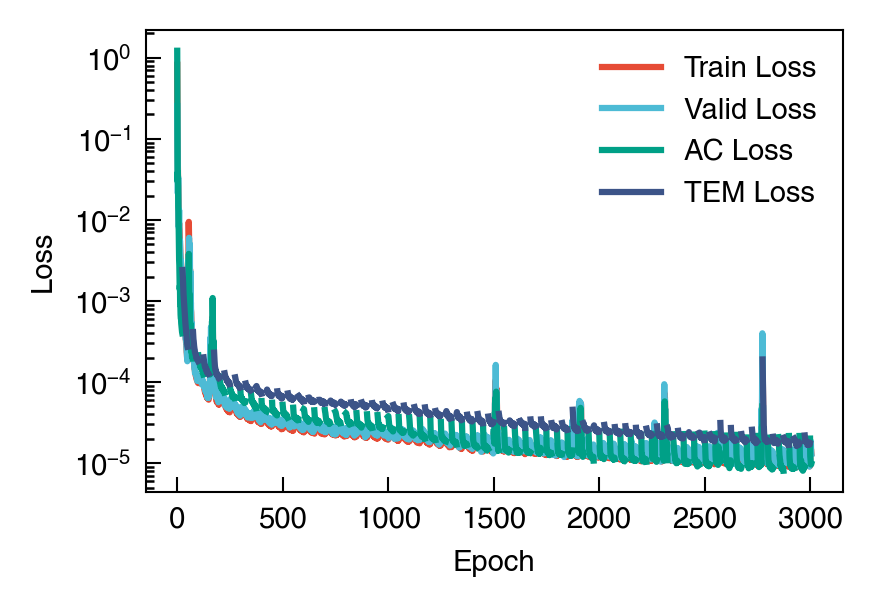

In [3]:
# read csv loss
import pandas as pd
save_dir = configs.save_dir
loss_df = pd.read_csv(os.path.join(save_dir, "logs.csv"))
fig, ax = plt.subplots(1, 1, figsize=(3, 2))
ax.plot(loss_df["Epoch"], loss_df["TrainLoss"], label="Train Loss")
ax.plot(loss_df["Epoch"], loss_df["ValidLoss"], label="Valid Loss")
if configs.physical_residual:
    ax.plot(loss_df["Epoch"], loss_df["ACLoss"], label="AC Loss")
    ax.plot(loss_df["Epoch"], loss_df["TEMLoss"], label="TEM Loss")
ax.legend()
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")

Text(0, 0.5, 'MSE')

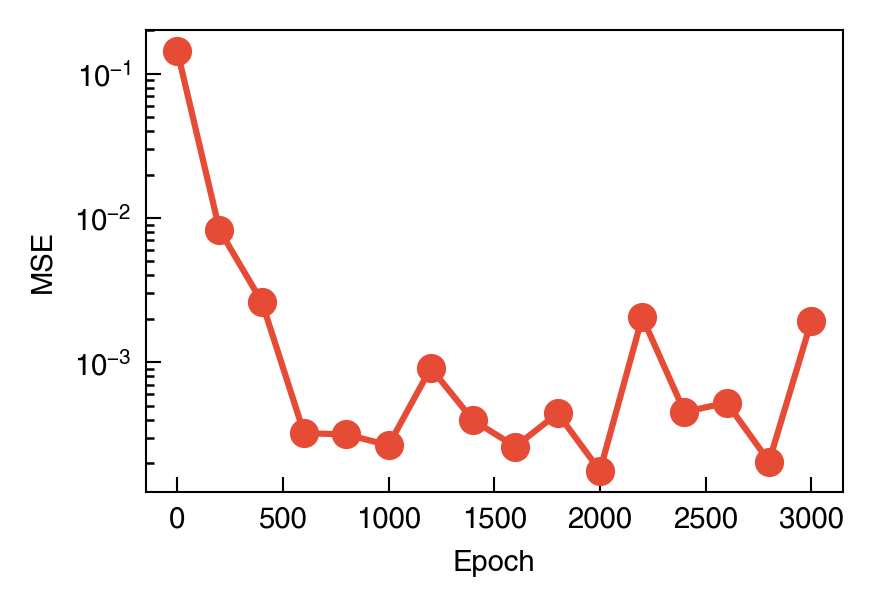

In [4]:
test_mse_df = pd.read_csv(os.path.join(save_dir, "test_logs.csv"))
fig, ax = plt.subplots(1, 1, figsize=(3, 2))
ax.plot(test_mse_df["Epoch"], test_mse_df["TestMSE"], label="Test MSE", marker='o')
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")

In [5]:
# from model import model1d
from solidification.model2d import get_model2d

model_kwargs = {
   'modes_x': configs.modes_x,
   'modes_y': configs.modes_x,
   'width': configs.width,
   'depth': configs.depth,
   'activation': getattr(jax.nn, configs.activation),
   'key': jax.random.PRNGKey(0),
}

# Add VAE-specific parameters if needed
if configs.model_type == 'vae':
   model_kwargs.update({
      'latent_dim': configs.latent_dim,
      'output_size': configs.output_size,
   })

model_skeleton = get_model2d(
   configs.model_type,
   configs.in_channels,
   configs.out_channels,
   **model_kwargs
)
# model_skeleton = get_model1d(configs, jax.random.PRNGKey(0))
# weight = os.path.join(save_dir, f"epoch_{configs.epochs - 1}.eqx")
weight = os.path.join(save_dir, f"epoch_2800.eqx")
model = eqx.tree_deserialise_leaves(weight, model_skeleton)

In [6]:
# data = jnp.load("./dataset_split.npz")
data = jnp.load(os.path.join(configs.data_dir, "dataset_split.npz"))

# Xs, Ys = data["train_x"], data["train_y"]
Xs, Ys = data["valid_x"], data["valid_y"]
meshes = jnp.load(os.path.join(configs.data_dir, "dataset_2d_complete.npz"))["meshes"]
times = jnp.load(os.path.join(configs.data_dir, "dataset_2d_complete.npz"))["times"]
dt = times[1] - times[0]
# meshes = jnp.transpose(meshes, (2, 0, 1))
meshesx = meshes[0]
meshesy = meshes[1]
Xs.shape, Ys.shape

((250, 5, 129, 129), (250, 2, 129, 129))

In [7]:
Xs[:, 2, 0, 0].shape

(250,)

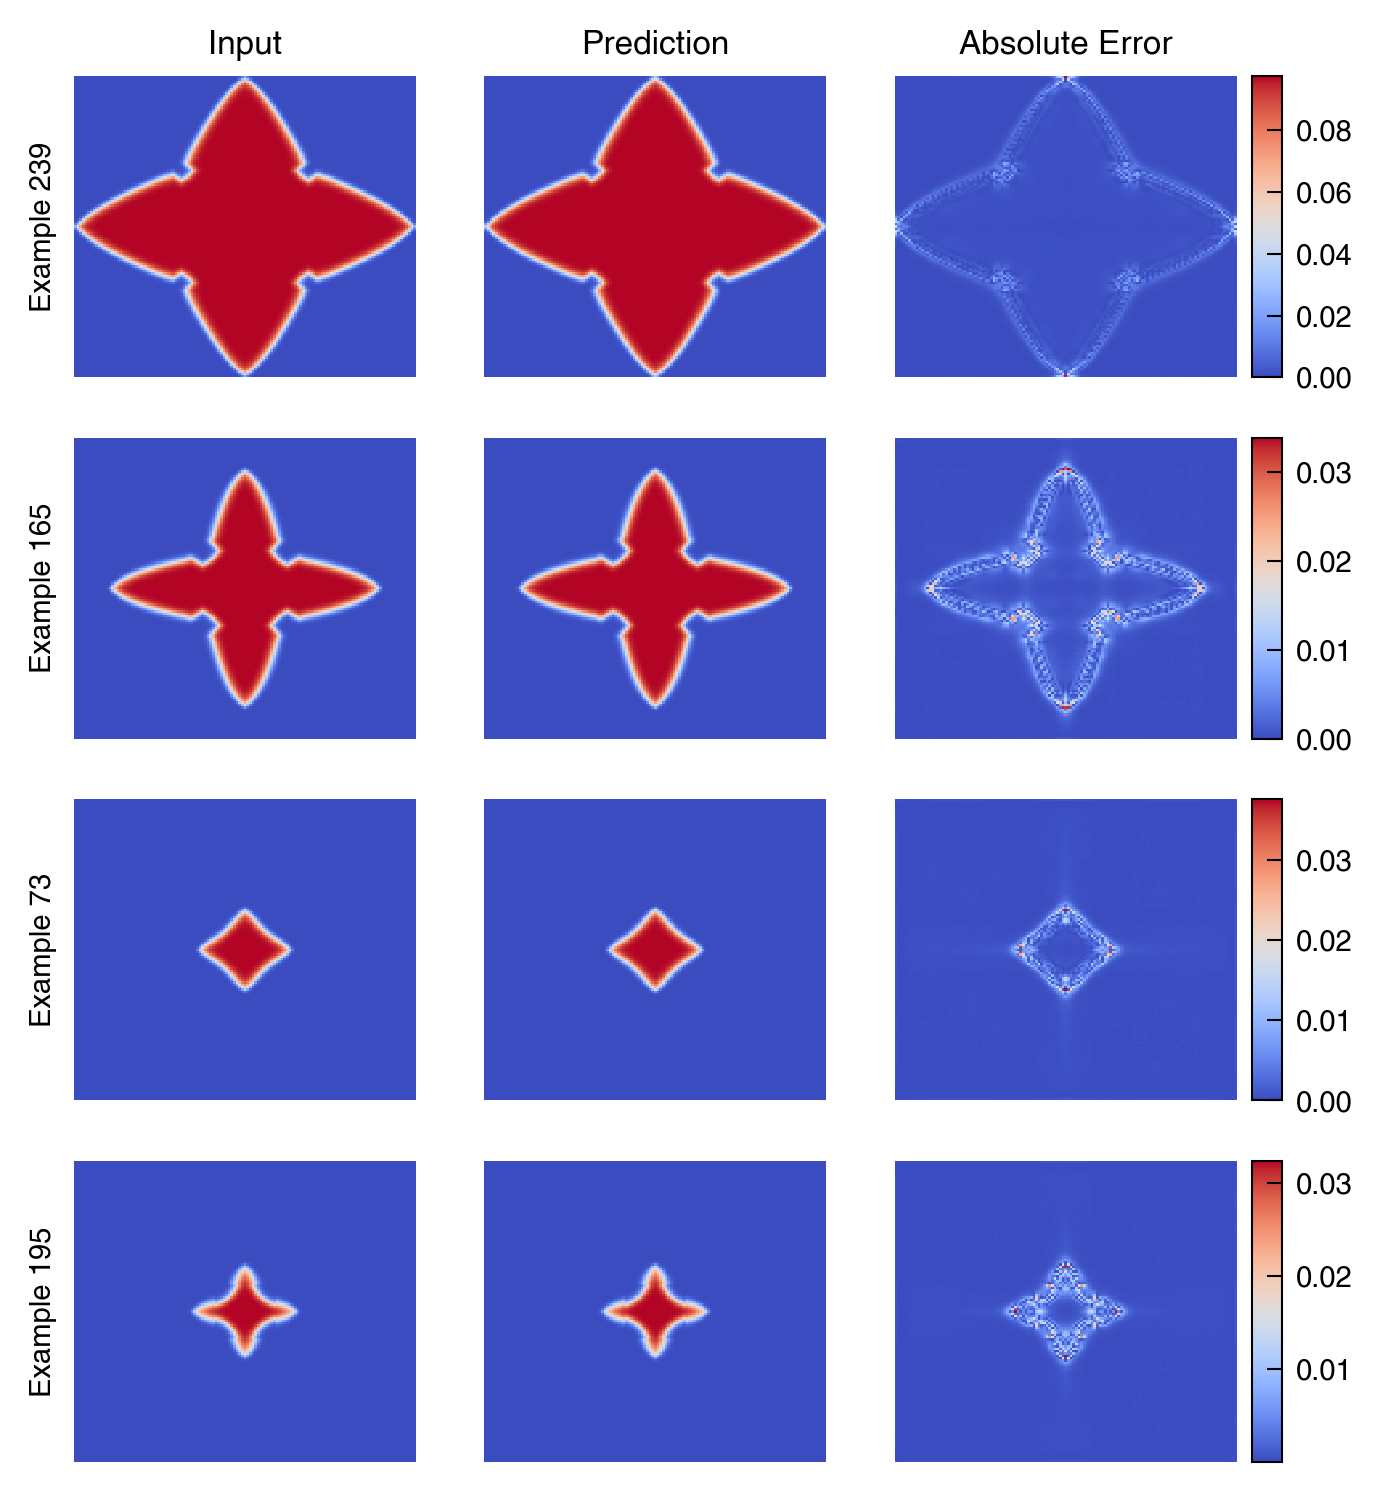

In [8]:
num_examples = 4
import numpy as np
random_indices = np.random.choice(Xs.shape[0], num_examples, replace=False)
fig, axes = plt.subplots(num_examples, 3, figsize=(5, 1.5 * num_examples))
xs_examples = Xs[random_indices]
ys_examples = Ys[random_indices]
# ks_examples = ks[random_indices]
y_pred_examples = jax.vmap(model.forward)(xs_examples)
component = 0

for i, idx in enumerate(random_indices):
    ax = axes[i, 0]
    # ax.contourf(meshesx, meshesy, xs_examples[i, 0, :, :], levels=100, cmap='coolwarm')
    ax.pcolormesh(meshesx, meshesy, xs_examples[i, component, :, :], shading='auto', cmap='coolwarm')
    ax.set_axis_off()
    # ax.set_ylabel(f"Example {idx}", rotation=0, labelpad=20, fontsize=8, va='center')
    ax.text(-0.05, 0.5, f"Example {idx}", rotation=90, va='center', ha="right", transform=ax.transAxes,)
    if i == 0:
        ax.text(0.5, 1.05, "Input", ha="center", va="bottom", transform=ax.transAxes, fontsize=8)

    ax = axes[i, 1]
    # ax.contourf(meshesx, meshesy, ys_examples[i, 0, :, :], levels=100, cmap='coolwarm')
    ax.pcolormesh(meshesx, meshesy, ys_examples[i, component, :, :], shading='auto', cmap='coolwarm')
    ax.set_axis_off()
    if i == 0:
        ax.text(0.5, 1.05, "Prediction", ha="center", va="bottom", transform=ax.transAxes, fontsize=8)

    ax = axes[i, 2]
    diff = jnp.abs(ys_examples[i, component, :, :] - y_pred_examples[i, component, :, :])
    # diff_ax = ax.contourf(meshesx, meshesy, diff, levels=100, cmap='coolwarm')
    diff_ax = ax.pcolormesh(meshesx, meshesy, diff, shading='auto', cmap='coolwarm')
    ax.set_axis_off()
    if i == 0:
        ax.text(0.5, 1.05, "Absolute Error", ha="center", va="bottom", transform=ax.transAxes, fontsize=8)

    ax_bar = fig.add_axes([ax.get_position().x1 + 0.01,
                           ax.get_position().y0,
                           0.02,
                           ax.get_position().height])
    fig.colorbar(diff_ax, cax=ax_bar)
# fig.tight_layout()

In [9]:
test_solutions = jnp.load(os.path.join(configs.test_data_dir, "solutions_grid.npy"))
test_ks = jnp.load(os.path.join(configs.test_data_dir, "K_values.npy")).reshape(-1, 1)
test_ks = test_ks[1:, :]
u0 = test_solutions[1:, 0, :, :]
y_test = test_solutions[1:, 1:, :, :]
auto_reg_fn = partial(
    model.auto_reg,
    meshes=meshes,
    steps=200
)
u_preds = jax.vmap(auto_reg_fn)(u0, test_ks)

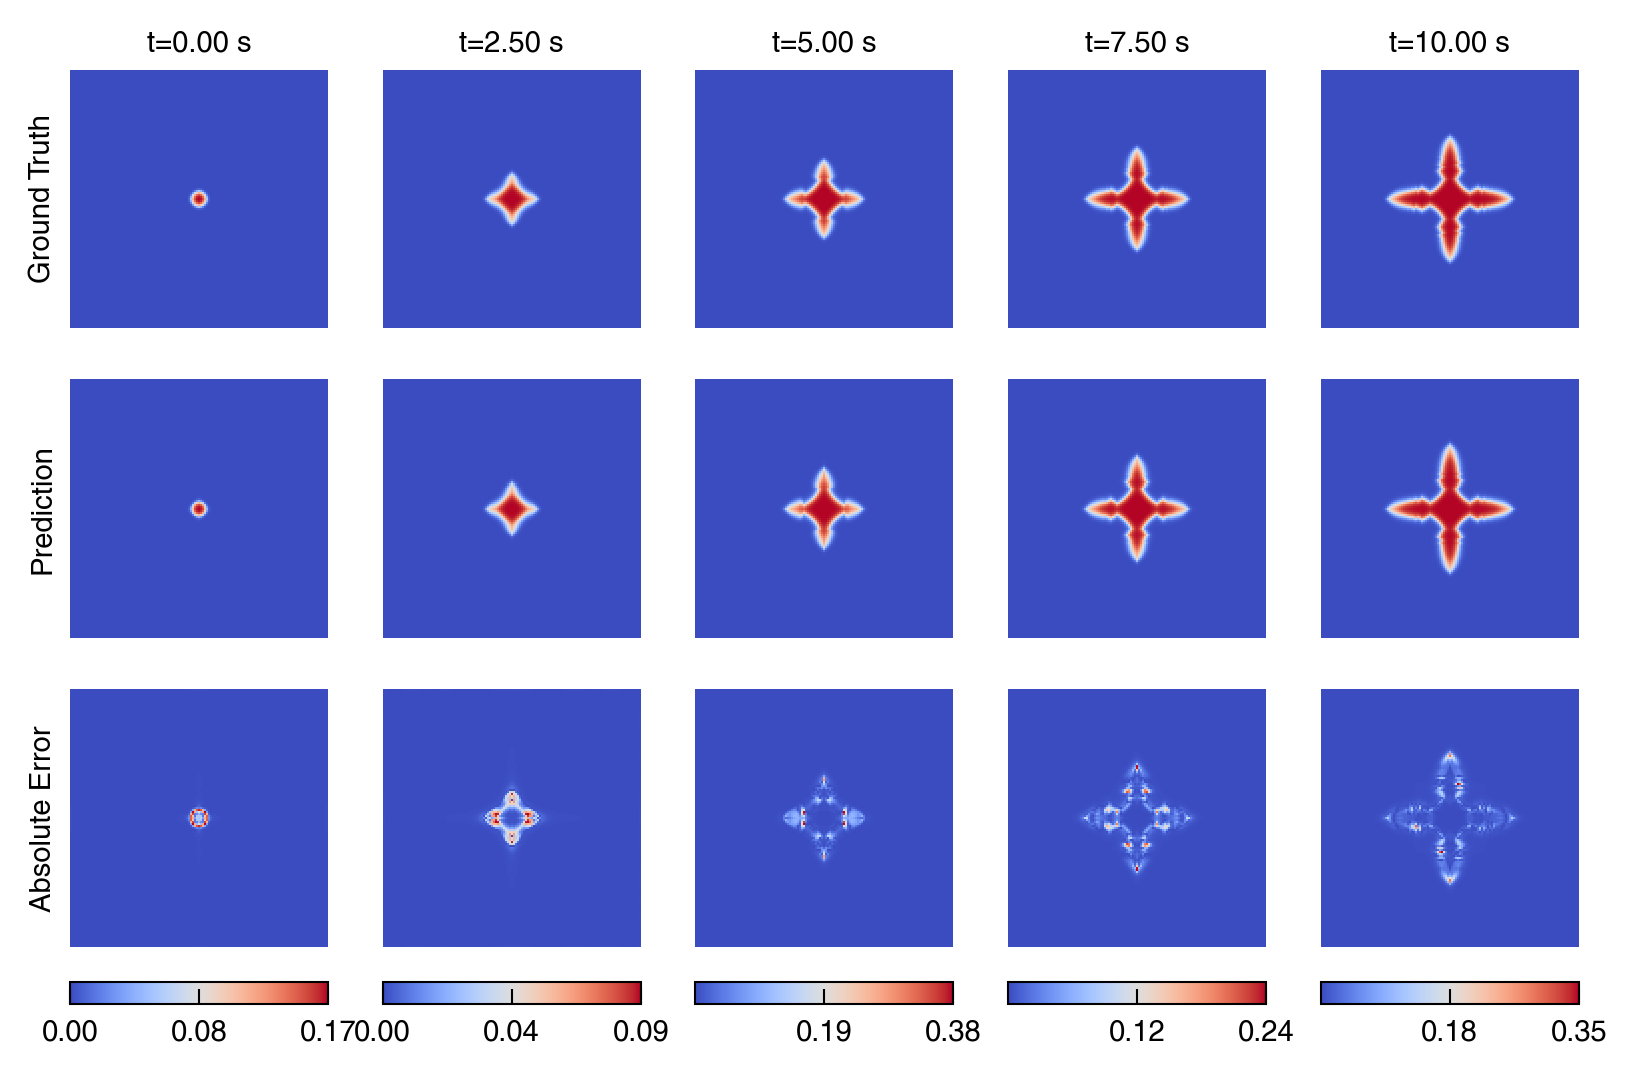

In [10]:
idxs = [0, 50, 100, 150, 200]
meshesx = meshes[0]
meshesy = meshes[1]
example_th = -1
component = 0
fig, axes = plt.subplots(3, len(idxs), figsize=(1.3 * len(idxs), 3.8),)
for i, idx in enumerate(idxs):
    ax = axes[0, i]
    # ax.contourf(meshesx, meshesy, y_test[example_th, idx, 0, :, :], levels=20, cmap='coolwarm')
    ax.pcolormesh(meshesx, meshesy, y_test[example_th, idx, component, :, :], shading='auto', cmap='coolwarm')
    if i == 0:
        ax.text(-0.05, 0.5, "Ground Truth", ha="right", va="center", transform=ax.transAxes, rotation=90)
    # ax.set_title(f"Ground Truth t={int((idx+1)*dt*configs.Tc)} s")
    ax.set_axis_off()
    ax.text(0.5, 1.05, f"t={idx*dt*configs.Tc:.2f} s", ha="center", va="bottom", transform=ax.transAxes)
    ax.set_aspect('equal')

    ax = axes[1, i]
    # ax.contourf(meshesx, meshesy, u_preds[example_th, idx, 0, :, :], levels=20, cmap='coolwarm')
    ax.pcolormesh(meshesx, meshesy, u_preds[example_th, idx, component, :, :], shading='auto', cmap='coolwarm')
    if i == 0:
        ax.text(-0.05, 0.5, "Prediction", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')

    ax = axes[2, i]
    diff = jnp.abs(y_test[example_th, idx, component, :, :] - u_preds[example_th, idx, component, :, :])
    # diff_ax = ax.contourf(meshesx, meshesy, diff, levels=20, cmap='coolwarm')
    diff_ax = ax.pcolormesh(meshesx, meshesy, diff, shading='auto', cmap='coolwarm')
    if i == 0:
        ax.text(-0.05, 0.5, "Absolute Error", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')
    ax_bar = fig.add_axes([ax.get_position().x0,
                           ax.get_position().y0 - 0.05,
                           ax.get_position().width,
                           0.02])
    
    # L2 = jnp.linalg.norm(y_test[example_th, idx, component, :, :] - u_preds[example_th, idx, component, :, :]) / jnp.linalg.norm(y_test[example_th, idx, component, :, :])
    # # format as latex string wish scientific notation (\times 10^)
    # L2_magnitude = jnp.floor(jnp.log10(L2))
    # L2_coefficient = L2 / (10 ** L2_magnitude)
    # L2_text = r"$L_2=" + f"{L2_coefficient:.2f}" + r"\times 10^{" + f"{int(L2_magnitude)}" + "}$"
    # ax.text(0.01, 0.99, L2_text, ha="left", va="top", transform=ax.transAxes, fontsize=5, color='white')
    
    # fewer ticks on colorbar with 2 precision
    fig.colorbar(diff_ax, cax=ax_bar, orientation='horizontal',
                 format='%.2f', ticks=jnp.linspace(0, jnp.max(diff), num=3))

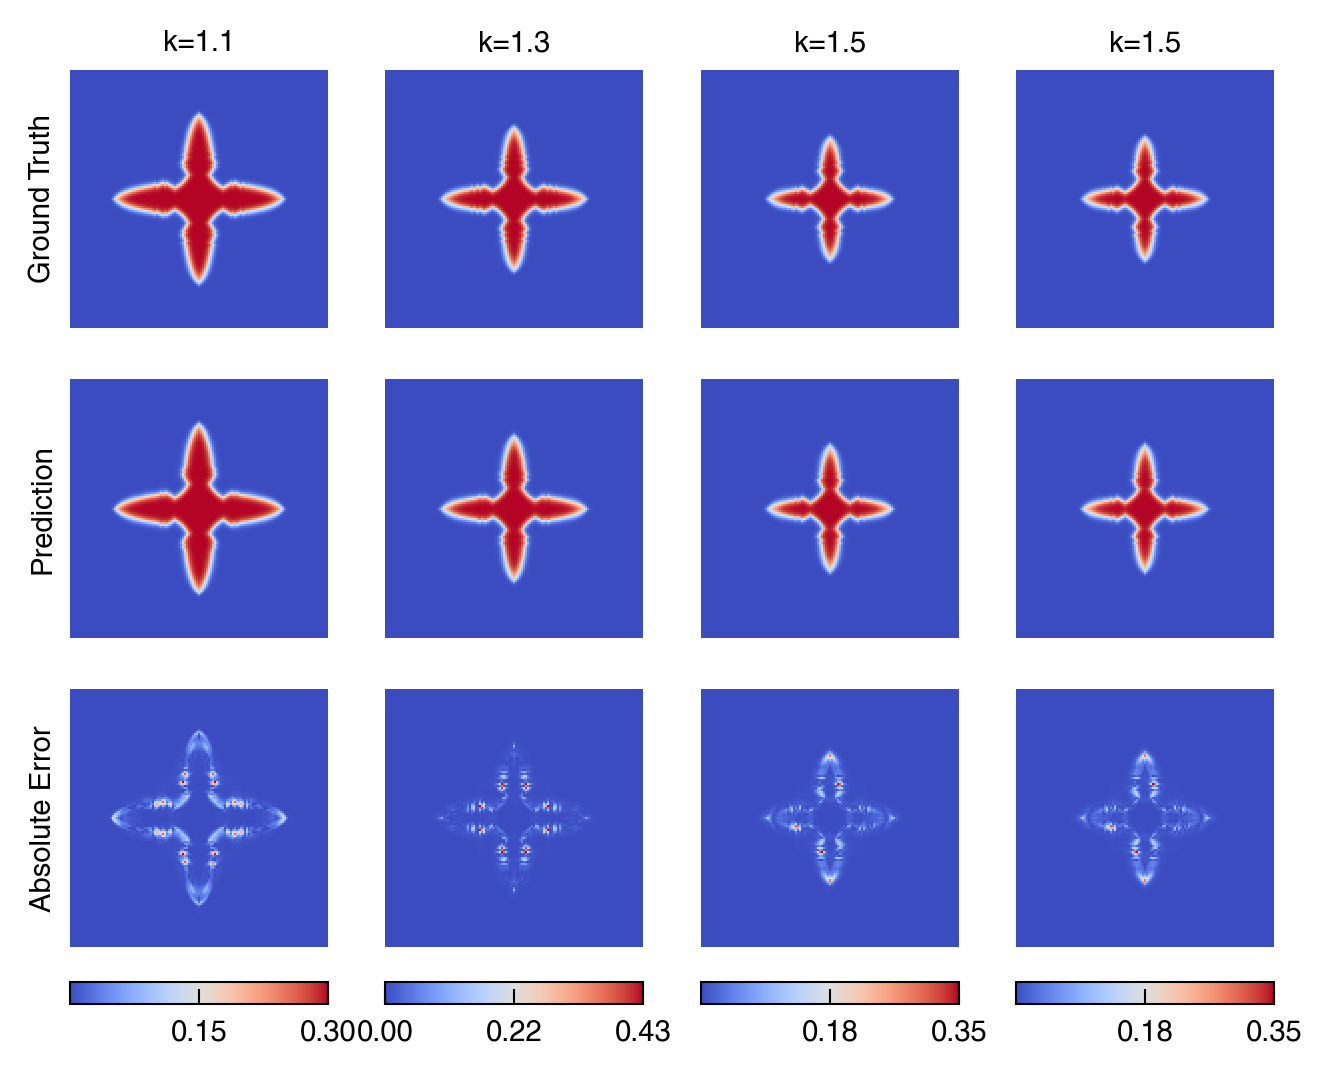

In [11]:
# Final time step, with different ks

meshesx = meshes[0]
meshesy = meshes[1]
example_ths = [1, 2, 3, 4]
idx = -1
component = 0
fig, axes = plt.subplots(3, len(example_ths), figsize=(1.3 * len(example_ths), 3.8),)
for i, example_th in enumerate(example_ths):
    ax = axes[0, i]
    # ax.contourf(meshesx, meshesy, y_test[example_th, idx, 0, :, :], levels=20, cmap='coolwarm')
    ax.pcolormesh(meshesx, meshesy, y_test[example_th, idx, component, :, :], shading='auto', cmap='coolwarm')
    if i == 0:
        ax.text(-0.05, 0.5, "Ground Truth", ha="right", va="center", transform=ax.transAxes, rotation=90)
    # ax.set_title(f"Ground Truth t={int((idx+1)*dt*configs.Tc)} s")
    ax.set_axis_off()
    ax.text(0.5, 1.05, f"k={test_ks[example_th, -1]:.1f}", ha="center", va="bottom", transform=ax.transAxes)
    ax.set_aspect('equal')

    ax = axes[1, i]
    # ax.contourf(meshesx, meshesy, u_preds[example_th, idx, 0, :, :], levels=20, cmap='coolwarm')
    ax.pcolormesh(meshesx, meshesy, u_preds[example_th, idx, component, :, :], shading='auto', cmap='coolwarm')
    if i == 0:
        ax.text(-0.05, 0.5, "Prediction", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')

    ax = axes[2, i]
    diff = jnp.abs(y_test[example_th, idx, component, :, :] - u_preds[example_th, idx, component, :, :])
    # diff_ax = ax.contourf(meshesx, meshesy, diff, levels=20, cmap='coolwarm')
    diff_ax = ax.pcolormesh(meshesx, meshesy, diff, shading='auto', cmap='coolwarm')
    if i == 0:
        ax.text(-0.05, 0.5, "Absolute Error", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')
    ax_bar = fig.add_axes([ax.get_position().x0,
                           ax.get_position().y0 - 0.05,
                           ax.get_position().width,
                           0.02])
    
    # L2 = jnp.linalg.norm(y_test[example_th, idx, component, :, :] - u_preds[example_th, idx, component, :, :]) / jnp.linalg.norm(y_test[example_th, idx, component, :, :])
    # # format as latex string wish scientific notation (\times 10^)
    # L2_magnitude = jnp.floor(jnp.log10(L2))
    # L2_coefficient = L2 / (10 ** L2_magnitude)
    # L2_text = r"$L_2=" + f"{L2_coefficient:.2f}" + r"\times 10^{" + f"{int(L2_magnitude)}" + "}$"
    # ax.text(0.01, 0.99, L2_text, ha="left", va="top", transform=ax.transAxes, fontsize=5, color='white')
    
    # fewer ticks on colorbar with 2 precision
    fig.colorbar(diff_ax, cax=ax_bar, orientation='horizontal',
                 format='%.2f', ticks=jnp.linspace(0, jnp.max(diff), num=3))

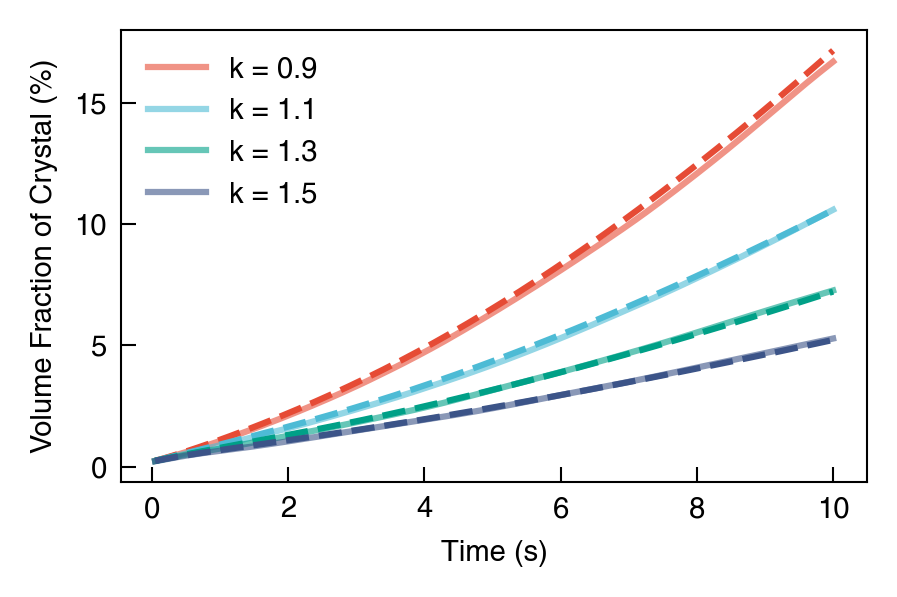

In [12]:
evo_frac = jnp.mean((y_test+1)/2, axis=(-1, -2))[..., 0]
evo_frac_pred = jnp.mean((u_preds+1)/2, axis=(-1, -2))[..., 0]

fig, ax = plt.subplots(1, 1, figsize=(3, 2))
for i in range( evo_frac.shape[0]):
    ax.plot(times[1:], evo_frac[i, :], color=f"C{i}", ls="--")
    ax.plot(times[1:], evo_frac_pred[i, :], color=f"C{i}", alpha=0.6, label=f"k = {test_ks[i,0]:.1f}")

# from matplotlib.lines import Line2D
# custom_lines = [Line2D([0], [0], color='black', ls='--'),
#                 Line2D([0], [0], color='black', ls='-')]
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x * 100:.0f}'))
ax.set_xlabel("Time (s)")
ax.set_ylabel("Volume Fraction of Crystal (%)")
fig.tight_layout()

In [13]:
# acc logs
test_solutions = jnp.load(os.path.join(configs.test_data_dir, "solutions_grid.npy"))
test_ks = jnp.load(os.path.join(configs.test_data_dir, "K_values.npy")).reshape(-1, 1)
test_ks = test_ks[1:, :]
# drop the first test example (cause it's speed is too fast, exceeding the domain.)
u0 = test_solutions[1:, 0, :, :]
y_test = test_solutions[1:, 1:, :, :]
epochs = jnp.arange(0, 3000, 200)
mse_list = []
for epoch in epochs:
    weight = os.path.join(save_dir, f"epoch_{epoch}.eqx")
    model = eqx.tree_deserialise_leaves(weight, model_skeleton)

    auto_reg_fn = partial(
        model.auto_reg,
        meshes=meshes,
        steps=200
    )
    u_preds = jax.vmap(auto_reg_fn)(u0, test_ks)

    mse = jnp.mean((y_test - u_preds) ** 2,)
    mse_list.append(mse)

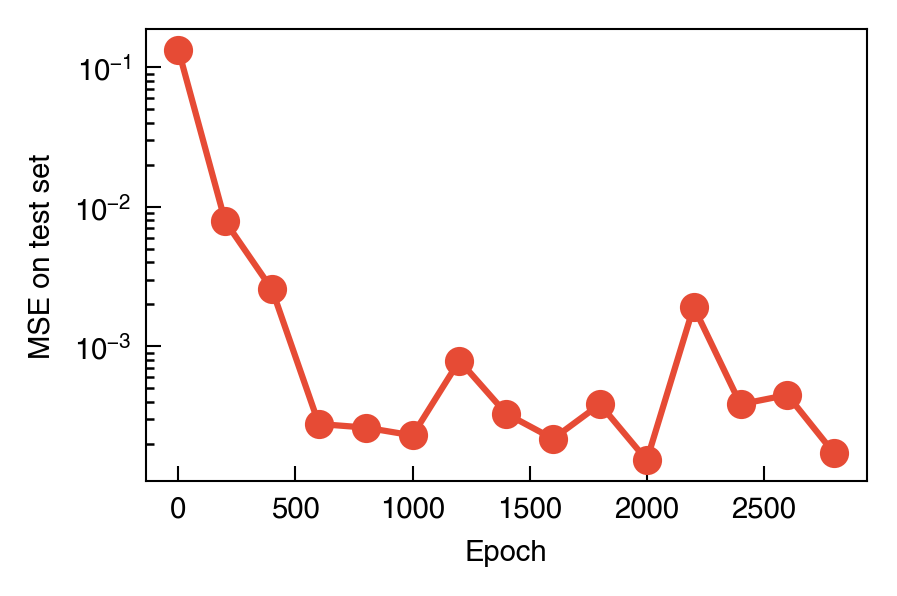

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2))
ax.plot(epochs, mse_list, marker='o')
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE on test set")
plt.tight_layout()

In [15]:
# save test mse
path = os.path.join(save_dir, "test_mse.npy")
jnp.save(path, jnp.array(mse_list))